In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import os


Original TTBar loss shape: (36, 4)
Original QCD loss shape: (36, 4)
Filtered TTBar loss shape: (17, 4)
Filtered QCD loss shape: (17, 4)


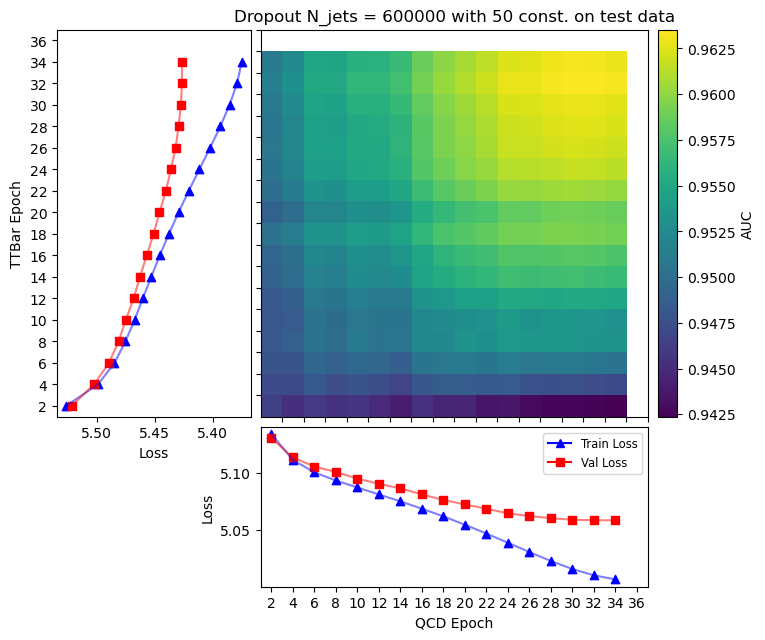

In [ ]:
# -----------------------
# CONFIG
# -----------------------

epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
tag = "test"  # test / train / val / sampled

n_jets = 600000
batch_size = 100
num_const = 50

trainings_run = f"JETCLASS_{n_jets}_cosine_restarts_orig"
base = f"/hpcwork/rwth0934/hep_foundation_model/classification/{trainings_run}/heatmap_{tag}/points"
base_train = f"/hpcwork/rwth0934/hep_foundation_model/training"

# -----------------------
# LOAD HEATMAP
# -----------------------
heatmap = np.zeros((len(epochs), len(epochs)))

for i, tt in enumerate(epochs):
    for j, qcd in enumerate(epochs):
        f = f"{base}/TTBar_{tt}_QCD_{qcd}.txt"
        if os.path.exists(f):
            heatmap[i, j] = float(open(f).read())
        else:
            print(f"Warning: File {f} not found. Setting AUC to 0.")
            heatmap[i, j] = np.nan  # or np.nan, depending on how you want to handle missing data

# -----------------------
# LOAD LOSS CURVES
# (replace with your actual loading)
# -----------------------
# Example placeholders:
ttbar_loss = pd.read_csv(f"{base_train}/{trainings_run}/TTBar_training_log.csv")
qcd_loss   = pd.read_csv(f"{base_train}/{trainings_run}/QCD_training_log.csv")

print("Original TTBar loss shape:", ttbar_loss.shape)
print("Original QCD loss shape:", qcd_loss.shape)

# Filter loss data to only include values corresponding to the epochs
steps_to_keep = [(epoch + 1) * (int(n_jets/batch_size)) for epoch in epochs]
ttbar_loss = ttbar_loss[ttbar_loss['step'].isin(steps_to_keep)].reset_index(drop=True)
qcd_loss = qcd_loss[qcd_loss['step'].isin(steps_to_keep)].reset_index(drop=True)

print("Filtered TTBar loss shape:", ttbar_loss.shape)
print("Filtered QCD loss shape:", qcd_loss.shape)

# -----------------------
# FIGURE LAYOUT
# -----------------------
fig = plt.figure(figsize=(8, 8))

gs = GridSpec(
    2, 3,
    width_ratios=[2, 4, 0.2],
    height_ratios=[4, 1.5],
    wspace=0.05,
    hspace=0.1
)

ax_left   = fig.add_subplot(gs[0, 0])
ax_heat   = fig.add_subplot(gs[0, 1])
ax_cbar   = fig.add_subplot(gs[0, 2])
ax_bottom = fig.add_subplot(gs[1, 1])

# -----------------------
# HEATMAP
# -----------------------
im = ax_heat.imshow(heatmap, origin="lower", aspect="equal")

# Correct ticks (same as your original script)
ax_heat.set_xticks(np.arange(len(epochs)) + 0.5)
ax_heat.set_xticklabels(epochs)

ax_heat.set_yticks(np.arange(len(epochs)) + 0.5)
ax_heat.set_yticklabels([])
ax_heat.tick_params(axis="y", labelleft=False)

ax_heat.set_title(f"Dropout N_jets = {n_jets} with {num_const} const. on {tag} data")

# -----------------------
# COLORBAR (separate axis)
# -----------------------
cbar = fig.colorbar(im, cax=ax_cbar)
cbar.set_label("AUC")

# -----------------------
# RESCALE LOSS CURVES TO HEATMAP INDEX SPACE
# -----------------------
y_tt = np.arange(len(ttbar_loss["step"])) + 0.5
x_qcd = np.arange(len(qcd_loss["step"])) + 0.5

# -----------------------
# LEFT: TTBar LOSS
# -----------------------
ax_left.scatter(ttbar_loss["train_loss"], y_tt, color = "blue", marker = "^")
ax_left.plot(ttbar_loss["train_loss"], y_tt, alpha = 0.5, color = "blue")  # optional line plot

ax_left.scatter(ttbar_loss["val_loss"], y_tt, color = "red", marker = "s")
ax_left.plot(ttbar_loss["val_loss"], y_tt, alpha = 0.5, color = "red")  # optional line plot

ax_left.invert_xaxis()
    
ax_left.set_ylim(0, len(epochs))
ax_left.set_xlabel("Loss")
ax_left.set_ylabel("TTBar Epoch")

# match tick positions visually with the heatmap
ax_left.set_yticks(np.arange(len(epochs)) + 0.5)
ax_left.set_yticklabels(epochs)
ax_left.tick_params(axis="y", labelleft=True)
ax_left.spines["left"].set_visible(True)
# hide heatmap y-axis labels, keep the ticks for alignment
ax_heat.tick_params(axis="y", labelleft=False)
ax_heat.yaxis.set_ticks_position("left")

# -----------------------
# BOTTOM: QCD LOSS

ax_bottom.scatter(x_qcd, qcd_loss["train_loss"], color = "blue", marker = "^")
ax_bottom.plot(x_qcd, qcd_loss["train_loss"], alpha = 0.5, color = "blue")  # optional line plot

ax_bottom.scatter(x_qcd, qcd_loss["val_loss"], color = "red", marker = "s")
ax_bottom.plot(x_qcd, qcd_loss["val_loss"], alpha = 0.5, color = "red")  # optional line plot

ax_bottom.set_xlim(0, len(epochs))
ax_bottom.set_xlabel("QCD Epoch")
ax_bottom.set_ylabel("Loss")

ax_bottom.set_xticks(np.arange(len(epochs)) + 0.5)
ax_bottom.set_xticklabels(epochs)

# -----------------------
# CLEANUP

ax_heat.tick_params(labelbottom=False)  # bottom plot handles x labels
ax_left.tick_params(labelright=False)
ax_bottom.tick_params(labeltop=False)

# -----------------------
# FORCE PERFECT ALIGNMENT

plt.draw()

pos = ax_heat.get_position()
pos_left = ax_left.get_position()
pos_bottom = ax_bottom.get_position()

left_gap = pos.x0 - pos_left.x1
bottom_gap = pos_bottom.y1 - pos.y0
# use the larger gap to keep both spaces consistent
gap = max(left_gap, bottom_gap)

ax_left.set_position([
    pos.x0 - gap - pos_left.width,
    pos.y0,
    pos_left.width,
    pos.height
])

ax_bottom.set_position([
    pos.x0,
    pos.y0 - gap - pos_bottom.height,
    pos.width,
    pos_bottom.height
])

# Match colorbar height
ax_cbar.set_position([
    ax_cbar.get_position().x0,
    pos.y0,
    ax_cbar.get_position().width,
    pos.height
])

# Add single legend for loss curves
handles = [
    plt.Line2D([0], [0], marker='^', color='blue', linestyle='-', label='Train Loss'),
    plt.Line2D([0], [0], marker='s', color='red', linestyle='-', label='Val Loss')
]
ax_bottom.legend(handles=handles, loc='upper right', fontsize='small')

# -----------------------
# SAVE

os.makedirs("plots", exist_ok = True)

plt.savefig(f"plots/heatmap_{trainings_run}_{tag}.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()
